In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

In [2]:
DATASET_PATH = "../dataset/bccc-cpacket-cloud-ddos-2024-merged.parquet"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}. "
        "Cek folder '../dataset/' (huruf kecil)."
    )

try:
    df = pd.read_parquet(DATASET_PATH, engine="pyarrow")
except Exception as e:
    print(f"[Warn] read_parquet(engine='pyarrow') failed: {e}")
    df = pd.read_parquet(DATASET_PATH)

df.head()

,src_port,dst_port,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,...,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label,activity
0,54573,25094,0.000063,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,25094,54573,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,54573,25094,0.000028,3,1,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,9147,18060,0.000055,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,18060,9147,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign


# Removing activity columns

In [3]:
if "activity" in df.columns:
    df = df.drop(columns=["activity"])

df.head()

,src_port,dst_port,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,...,min_fwd_payload_bytes_delta_len,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label
0,54573,25094,0.000063,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,25094,54573,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,54573,25094,0.000028,3,1,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,9147,18060,0.000055,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,18060,9147,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 540494 entries, 0 to 540493
Columns: 318 entries, src_port to label
dtypes: float32(261), int16(9), int32(20), int64(2), int8(25), str(1)
memory usage: 617.1 MB


In [5]:
df.shape

(540494, 318)

In [6]:
string_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
string_cols

['label']

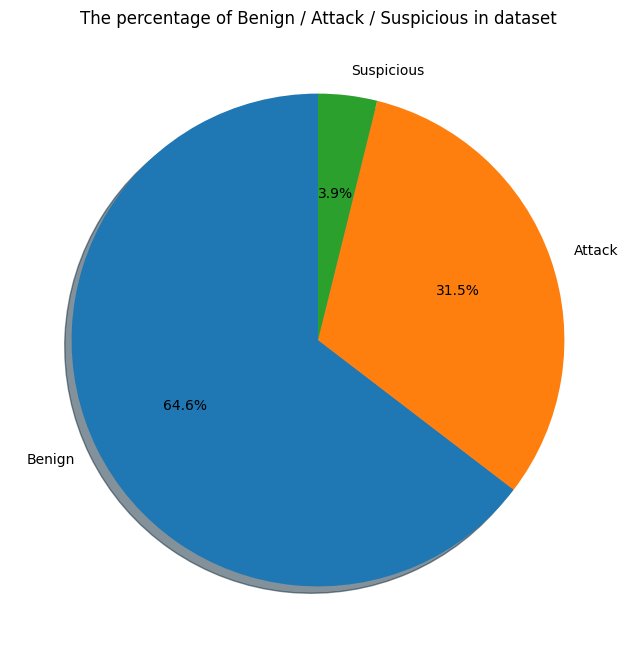

In [7]:
counts_dict = dict(df.label.value_counts())

labels = ["Benign", "Attack", "Suspicious"]
sizes = [
    counts_dict.get("Benign", 0),
    counts_dict.get("Attack", 0),
    counts_dict.get("Suspicious", 0),
]

plt.figure(figsize=(13, 8))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", shadow=True, startangle=90)
plt.title("The percentage of Benign / Attack / Suspicious in dataset")
plt.show()

## Convert labels into numerical

In [8]:
df["label"].value_counts()

label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64

In [9]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])

print("Label mapping (class -> encoded):")
for cls in le.classes_:
    print(f"  {cls}: {int(le.transform([cls])[0])}")

df["label"].value_counts()

Label mapping (class -> encoded):
  Attack: 0
  Benign: 1
  Suspicious: 2


label
1    349178
0    170436
2     20880
Name: count, dtype: int64

## Dataset splitting

In [10]:
X = df.drop(columns=["label"])
y = df["label"]

non_numeric_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
if non_numeric_cols:
    raise ValueError(f"Found non-numeric feature columns: {non_numeric_cols}")

# Final split: 60% train, 20% val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print("Shapes:")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("  X_test: ", X_test.shape, "y_test: ", y_test.shape)

Shapes:
  X_train: (324296, 317) y_train: (324296,)
  X_val:   (108099, 317) y_val:   (108099,)
  X_test:  (108099, 317) y_test:  (108099,)


# Feature Engineering (train-only)

In [11]:
# 1) Remove zero-variance features (based on train)
zero_var_cols = [col for col in X_train.columns if X_train[col].nunique(dropna=False) <= 1]
if zero_var_cols:
    X_train = X_train.drop(columns=zero_var_cols)
    X_val   = X_val.drop(columns=zero_var_cols)
    X_test  = X_test.drop(columns=zero_var_cols)
print(f"[Prep] Dropped {len(zero_var_cols)} zero-variance columns.")

# 2) Remove highly correlated features (>0.95) using a sample of train
sample_n = min(50_000, len(X_train))
corr_sample = X_train.sample(n=sample_n, random_state=42)
corr_matrix = corr_sample.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
if high_corr_cols:
    X_train = X_train.drop(columns=high_corr_cols)
    X_val   = X_val.drop(columns=high_corr_cols)
    X_test  = X_test.drop(columns=high_corr_cols)
print(f"[Prep] Dropped {len(high_corr_cols)} highly-correlated columns (>0.95).")

X_train.shape

[Prep] Dropped 3 zero-variance columns.
[Prep] Dropped 169 highly-correlated columns (>0.95).


(324296, 145)

In [12]:
import pickle

preprocess_info = {
    "zero_var_cols": zero_var_cols,
    "high_corr_cols": high_corr_cols,
    "feature_columns": X_train.columns.tolist(),
}
with open("svm_preprocess_info.pkl", "wb") as f:
    pickle.dump(preprocess_info, f)
print("[Output] Preprocessing info saved to svm_preprocess_info.pkl.")

[Output] Preprocessing info saved to svm_preprocess_info.pkl.


## Modeling (Scaling + Linear SVM)

In [13]:
from sklearn.linear_model import SGDClassifier

svm_clf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "svm",
            SGDClassifier(
                loss="hinge",              # This makes it a Linear SVM
                penalty="l2",
                alpha=0.0001,              # Equivalent to 1/C
                class_weight="balanced",
                max_iter=1000,             # SGD needs far fewer iterations
                random_state=42,
                n_jobs=-1                  # Uses all CPU cores if multiclass
            ),
        ),
    ]
)

print("[SVM] Fitting...")
svm_clf.fit(X_train, y_train)
print("[SVM] Fit complete.")

val_pred = svm_clf.predict(X_val)
print(f"[Val] Macro F1:    {f1_score(y_val, val_pred, average='macro'):.4f}")
print(f"[Val] Weighted F1: {f1_score(y_val, val_pred, average='weighted'):.4f}")

[SVM] Fitting...
[SVM] Fit complete.
[Val] Macro F1:    0.6956
[Val] Weighted F1: 0.8961


## Evaluation

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Predict class labels
val_pred = svm_clf.predict(X_val)

# Decision scores for ROC‑AUC (works for multi‑class)
val_scores = svm_clf.decision_function(X_val)

# Classification metrics (weighted average for 3 classes)
accuracy = accuracy_score(y_val, val_pred)
precision = precision_score(y_val, val_pred, average='weighted')
recall = recall_score(y_val, val_pred, average='weighted')
f1 = f1_score(y_val, val_pred, average='weighted')

print("--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

--- Classification Metrics ---
Accuracy:  0.8962
Precision: 0.9050
Recall:    0.8962
F1-score:  0.8961


In [17]:
from sklearn.preprocessing import label_binarize
val_scores = svm_clf.decision_function(X_val)
n_classes = len(svm_clf.classes_)
y_val_bin = label_binarize(y_val, classes=range(n_classes))

auc_per_class = []
for i in range(n_classes):
    auc_i = roc_auc_score(y_val_bin[:, i], val_scores[:, i])
    auc_per_class.append(auc_i)

roc_auc_macro = sum(auc_per_class) / n_classes

print("\n--- ROC-AUC (macro, from decision function) ---")
for i, auc_val in enumerate(auc_per_class):
    print(f"  Class {i}: {auc_val:.4f}")
print(f"  Macro average: {roc_auc_macro:.4f}")


--- ROC-AUC (macro, from decision function) ---
  Class 0: 0.9511
  Class 1: 0.9556
  Class 2: 0.8584
  Macro average: 0.9217


In [ ]:
print("[SVM] Predicting on test set...")
y_pred_encoded = svm_clf.predict(X_test)

y_pred_labels = le.inverse_transform(y_pred_encoded)
y_test_labels = le.inverse_transform(y_test)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test_labels, y_pred_labels, digits=4))

macro_f1 = f1_score(y_test_labels, y_pred_labels, average="macro")
weighted_f1 = f1_score(y_test_labels, y_pred_labels, average="weighted")
print("KEY METRICS:")
print(f"  Macro F1:    {macro_f1:.4f}  ← Primary")
print(f"  Weighted F1: {weighted_f1:.4f}  ← Secondary")

[SVM] Predicting on test set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Attack     0.9808    0.7860    0.8726     34087
      Benign     0.9071    0.9866    0.9452     69836
  Suspicious     0.2503    0.2895    0.2685      4176

    accuracy                         0.8964    108099
   macro avg     0.7127    0.6873    0.6954    108099
weighted avg     0.9050    0.8964    0.8961    108099

KEY METRICS:
  Macro F1:    0.6954  ← Primary
  Weighted F1: 0.8961  ← Secondary


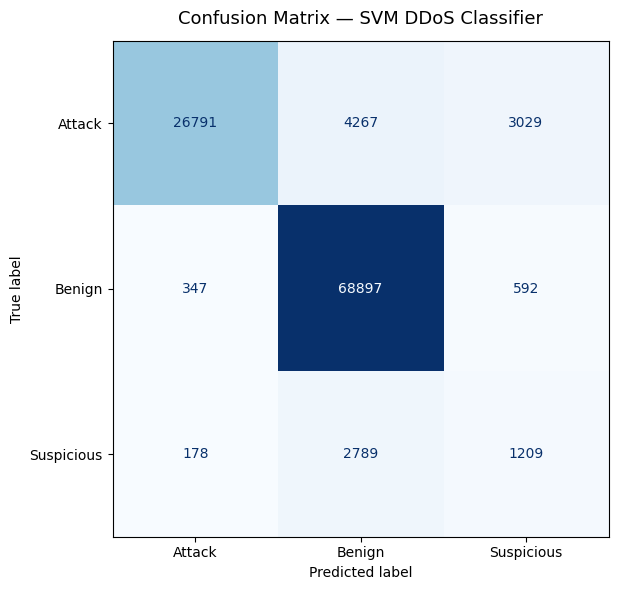

[Output] Confusion matrix saved → svm_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — SVM DDoS Classifier", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png", dpi=150)
plt.show()
print("[Output] Confusion matrix saved → svm_confusion_matrix.png")

## Save the trained model

In [ ]:
model_filename = 'svm_model.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(svm_clf, f)

print(f"[Output] Trained model saved to '{model_filename}'")

[Output] Trained model saved to 'svm_model.pkl'
